## Study Case - Student Competency Evaluation

A high school wants to evaluate the effectiveness of a new learning method it will implement. The principal sets a target that the average student score must be above the competency standard of 8. If the population average is proven to be greater than this figure, then the learning method is considered successful. The school takes a random sample of 200 students from the population.

### Define Hypothesis

The null hypothesis states that the new learning method has no significant impact on student performance. We need to gather sample data to prove otherwise.

$$ H_0: \mu \leq 8$$
$$ H_1: \mu > 8 $$

- where $\mu$ is the mean of GPA
- The significance level used is $\alpha$ = 0.01

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_1samp
import scipy.stats as stats
import matplotlib.pyplot as plt

In [43]:
student = pd.read_csv('Student Depression Dataset - Copy.csv')

Mean CGPA in samples  = 7.63
Std  CGPA in samples  = 1.49


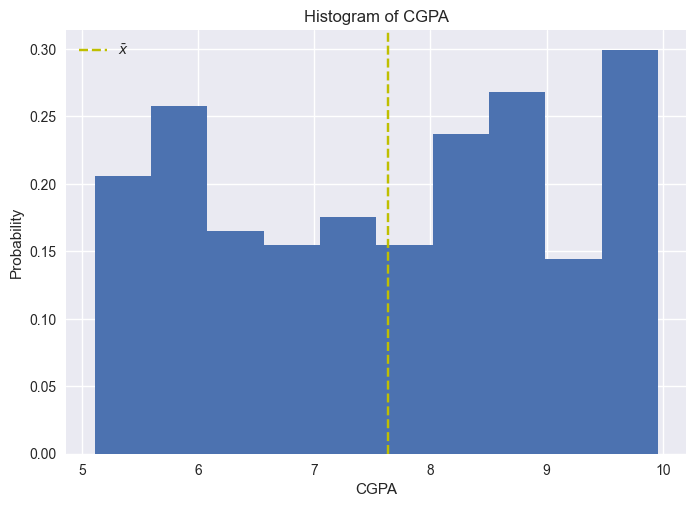

In [44]:
plt.hist(student['CGPA'], density=True)

mean_CGPA = np.mean(student['CGPA'])
std_CGPA  = np.std(student['CGPA'], ddof=1)

print(f'Mean CGPA in samples  = {np.round(mean_CGPA, 2)}')
print(f'Std  CGPA in samples  = {np.round(std_CGPA,  2)}')

plt.axvline(mean_CGPA, color='y', linestyle='--', label=r'$\bar{x}$')
plt.xlabel('CGPA')
plt.ylabel('Probability')
plt.title('Histogram of CGPA')
plt.legend()
plt.show()

From the histogram, the sample mean CGPA is approximately **7.62**, which is below the target of 8.0. However, this does not immediately confirm H₀, because:
- The histogram displays CGPA **per individual**, not the distribution of the sample mean.
- We are interested in whether the population mean ($\mu$) exceeds 8.0, not individual values.
- To formally test this, we need to measure how far ($\bar{x}$) is $\mu_0$ = 8 relative to the sampling variability — this is what the t-statistic captures.

Since we are using the sample mean to estimate the population mean ($\mu$) of the students CGPA, and even though we have a fairly large sample (more than 30 observations), we do not know the population standard deviation ($\sigma$) — we use a t-test instead of a z-test.

### Compute t-Statistic

The t-statistic (t-statistic) is a number that shows how far the difference is between your sample data and the initial hypothesis, when measured using standard deviation.

We use `ttest_1samp` with `alternative=`'greater' to perform the one-tailed right-tail test against $\mu_0$ = 8

In [45]:
t_statistics, p_value = ttest_1samp(
    a          = student['CGPA'],
    popmean    = 8,
    alternative= 'greater'   
)

print(f't stats  : {t_statistics:.4f}')
print(f'p-value  : {p_value:.4f}')

t stats  : -3.4976
p-value  : 0.9997


Next, we will determine the critical value at the 1% significance level to compare with the results of the t-statistic test.

- The critical value is determined using the t-distribution with df = n − 1 = 199 at a significance level of $\alpha$ = 0.01
- For a right-tail test, the rejection region lies to the right of $t_{crit}$

In [46]:
# t-critical for one-tailed (right tail), alpha = 0.01
t_crit = stats.t.ppf(1 - 0.01, df=199)
print(t_crit)

2.3452322311103635


- Make decision rule

We use two equivalent methods to make a decision:

- **Method 1 (p-value approach)**: if $p\text{-value} < \alpha, \text{ reject } H_0.$

- **Method 2 (critical value approach)**: if $t_{statistic} > t_{crit}, \text{ reject } H_0$


Both methods will always yield the same conclusion.

In [47]:
if p_value < 0.01:
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis')

Failed to reject the null hypothesis


In [48]:
# Metode 2 — pakai t-statistic vs t-critical
if t_statistics > t_crit:   
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis')

Failed to reject the null hypothesis


- Visualize the critical region

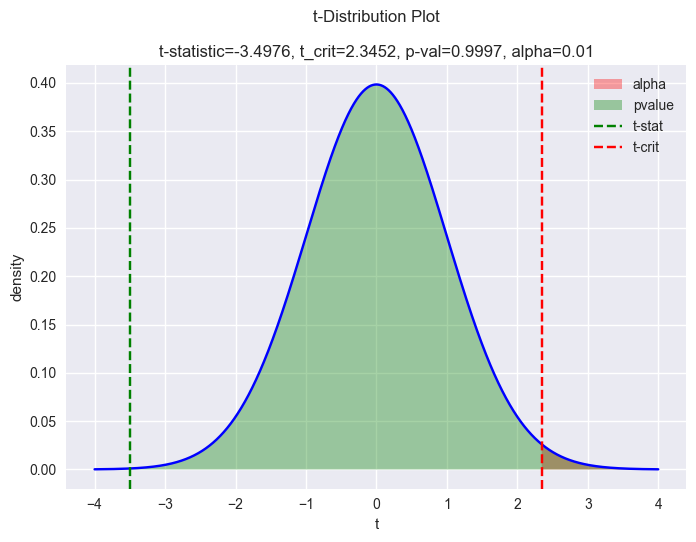

In [49]:

plt.style.use('seaborn-v0_8')

x = np.arange(-4, 4, 0.001)   
plt.plot(x, stats.t.pdf(x, df=199), color='blue')

# Alpha region (right tail)
x_alpha = np.arange(t_crit, 4, 0.01)
y_alpha = stats.t.pdf(x_alpha, df=199)
plt.fill_between(x_alpha, y_alpha, facecolor='red', alpha=0.35, label='alpha')

# p-value region
x_pvalue = np.arange(t_statistics, 4, 0.01)
y_pvalue = stats.t.pdf(x_pvalue, df=199)
plt.fill_between(x_pvalue, y_pvalue, facecolor='green', alpha=0.35, label='pvalue')

plt.axvline(np.round(t_statistics, 4), color='green', linestyle='--', label='t-stat')
plt.axvline(t_crit,                    color='red',   linestyle='--', label='t-crit')

plt.legend()
plt.xlabel('t')
plt.ylabel('density')
plt.title(
    f't-Distribution Plot\n\n'
    f't-statistic={np.round(t_statistics,4)}, '
    f't_crit={np.round(t_crit,4)}, '
    f'p-val={np.round(p_value,4)}, alpha=0.01'
)
plt.show()

- The plot above shows the t-distribution under $H_0$. The **red region** (right of $t_{crit}$) is the rejection zone at $\alpha$ = 0.01. 
- The **green region** represents the p-value - the probability of observing a t-statistic as extreme as ours, assuming $H_0$ is true.
- If the green region (p-value) is smaller than the red region (alpha), we reject H$H_0$


The next step is to calculate a 95% confidence interval using the `tconfint_generic` function. This step aims to estimate the range of the population mean parameter values ​​based on a given confidence level.

In [50]:
from statsmodels.stats.weightstats import _tconfint_generic

ci_low, ci_upp = _tconfint_generic(mean = mean_CGPA, 
                                   std_mean = std_CGPA / np.sqrt(len(student)), 
                                   dof = 199, alpha=0.05, 
                                   alternative='two-sided')

print(f"CGPA in School area lies between {ci_low:.2f} and {ci_upp:.2f}")

CGPA in School area lies between 7.42 and 7.84


But what happen with 8 that lies inside this interval?
- Since the p-value > alpha, we fail to reject $H_0$. This is consistent with our hypothesis test result — we fail to reject $H_0$.
- However, note that the CI approach uses a two-sided interval, while our hypothesis is one-tailed. This makes the CI less precise for this specific question. A one-tailed test is more appropriate when the direction of the effect matters, as it concentrates the entire $\alpha$ on one side and yields a sharper decision boundary.

## Conclusion

 - Based on the one-sample t-test at $\alpha$ = 0.01 we **fail to reject** $H_0$​. 
 - There is insufficient statistical evidence to conclude that the population mean CGPA exceeds 8.0.

### Recommendations

1. **Revise the target or baseline**. The sample mean CGPA of 7.62 is 0.38 points below the target of 8.0. The school should evaluate whether the 8.0 benchmark is realistic for this student population, or whether it needs to be recalibrated before the new learning method is rolled out more broadly.

2. **Investigate root causes**. The school may want to explore other variables in the dataset (e.g., academic pressure, sleep duration, financial stress) that could be contributing to lower CGPA outcomes, as these factors may be affecting student performance independently of the learning method.

3. **Collect more data or run a pilot program**. With a larger or more targeted sample, a follow-up study after implementing the learning method could provide stronger evidence of its effectiveness over time.